Prueba tecnica sobre una base de datos para AtentaMente\
Participant: Aldo Emmanuel Gutierrez De La Torre

La mayoria de estas paqueterias vienen instaladas por defecto en el entorno de python, comunmente anaconda, pero en unidecode, no necesariamente, por eso de deja el pip install por si se marca algun error.

In [33]:
!pip install Unidecode   #necesitamos instalar esta paqueteria, si queremos retirar acentos de manera rapida

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.2 MB/s eta 0:00:00


In [43]:
import pandas as pd  #primer espacio para librerias.
from unidecode import unidecode
import matplotlib.pyplot as plt

In [4]:
df=pd.read_excel("Base para prueba (1) (1).xlsx") #cargamos los datos y los hacemos un panda para proceder con el analisis

In [5]:
df.shape #654 regristros y 10 columnas

(654, 10)

In [6]:
df.head(6)   #visualizamos los primeros 6 registros para ver un poco como es la informacion

,Fuente,Nombre,Primer apellido,Segundo apellido,Email,asistencia_ses1,asistencia_ses2,asistencia_ses3,asistencia_ses4,asistencia_ses5
0,base1,JORGE JAVIER,TZAB,TURRIZA,jorgejaviertzabturriza@gmail.com,1.0,0.0,1.0,0.0,1.0
1,base1,KARINA RUBI,COLLI,CHE,karinarubicolliche@gmail.com,0.0,0.0,0.0,0.0,0.0
2,base1,MARCELA,HAAS,CHI,marcelahaaschi@gmail.com,0.0,0.0,0.0,0.0,0.0
3,base1,DANIELI MAEYVIS,CHAB,HERNANDEZ,danielimaeyvischabhernandez@gmail.com,0.0,1.0,0.0,0.0,0.0
4,base1,YULY BIANEY,SANCHEZ,DZUL,yulybianeysanchezdzul@gmail.com,0.0,0.0,0.0,0.0,1.0
5,base1,JUANA MARIA,GONZALEZ,CEH,juanamariagonzalezceh@gmail.com,0.0,0.0,1.0,0.0,0.0


In [7]:
df.info()  #revisamos como estan los datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Fuente            654 non-null    object 
 1   Nombre            654 non-null    object 
 2   Primer apellido   654 non-null    object 
 3   Segundo apellido  654 non-null    object 
 4   Email             654 non-null    object 
 5   asistencia_ses1   642 non-null    float64
 6   asistencia_ses2   644 non-null    float64
 7   asistencia_ses3   649 non-null    float64
 8   asistencia_ses4   642 non-null    float64
 9   asistencia_ses5   644 non-null    float64
dtypes: float64(5), object(5)
memory usage: 51.2+ KB


In [8]:
df.columns   #las comunas que tenemos para hacer el analisis

Index(['Fuente', 'Nombre', 'Primer apellido', 'Segundo apellido', 'Email',
       'asistencia_ses1', 'asistencia_ses2', 'asistencia_ses3',
       'asistencia_ses4', 'asistencia_ses5'],
      dtype='object')

In [9]:
df.isna().sum()  #observamos que existen valores vacios en las asistencia pero no el nos nombres o correo. Pero algunos nombres son muy cortos, pueden estar mal

,0
Fuente,0
Nombre,0
Primer apellido,0
Segundo apellido,0
Email,0
asistencia_ses1,12
asistencia_ses2,10
asistencia_ses3,5
asistencia_ses4,12
asistencia_ses5,10


Los datos que no estan rellenos son las asistencias, podemos rellenar como no asistido todos esos valores

In [10]:
#primero aplicamos un lower y un strip, lo que hace los correos en letra minusculas y sin espacios para que los datos no esten incorrectos
df["Email"] = df["Email"].str.lower().str.strip()

In [11]:
df["Email"].duplicated().sum()  #primero vamos a filtrar por correo para saber si hay duplicados

np.int64(101)

Aqui tenemos de momento 101 correos repetidos, pueden ser por tener las bases combinadas

In [12]:
#notamos que hay nombres muy cortos entonces vamos a verificar nombres, apellidos ya que si son muy cortos puede que no sean buenos registros
df[df["Nombre"].str.len() <= 2]
df[df["Primer apellido"].str.len() <= 2]
df[df["Segundo apellido"].str.len() <= 2]

,Fuente,Nombre,Primer apellido,Segundo apellido,Email,asistencia_ses1,asistencia_ses2,asistencia_ses3,asistencia_ses4,asistencia_ses5
41,base1,CRISTELL ESMERALDA,POOT,UC,cristellesmeraldapootuc@gmail.com,0.0,1.0,0.0,0.0,1.0
71,base1,SANDRA BEATRIZ,CHAN,YE,sandrabeatrizchanye@gmail.com,0.0,0.0,0.0,0.0,0.0
74,base1,IRINEO,HEREDIA,ZI,irineoherediazi@gmail.com,1.0,0.0,1.0,1.0,0.0
76,base1,EDGAR JULIAN,TREJO,UU,edgarjuliantrejouu@gmail.com,1.0,0.0,0.0,1.0,1.0
79,base1,LEANDRO MATIAS,MAY,EK,leandromatiasmayek@gmail.com,1.0,0.0,1.0,0.0,0.0
92,base1,CRISTIAN ORLANDO,DIAZ,KU,cristianorlandodiazku@gmail.com,1.0,1.0,1.0,0.0,0.0
128,base1,CESAR AUGUSTO,TAMAYO,UC,cesaraugustotamayouc@gmail.com,1.0,0.0,0.0,0.0,0.0
139,base1,REYNALDO,CAHUM,UC,reynaldocahumuc@gmail.com,1.0,0.0,0.0,1.0,0.0
142,base1,JAVIER ALFONSO,CORONA,UC,javieralfonsocoronauc@gmail.com,0.0,0.0,0.0,0.0,0.0
161,base1,LUCIANO GUADALUPE,CHI,UC,lucianoguadalupechiuc@gmail.com,0.0,0.0,1.0,0.0,0.0


Vemos que los nombres se ven bien, pero algunos apellidos se ven irregulares sobre todo el segudno apellido

In [13]:
cols_asistencia = [  #creamos la lista de asistencia, que son 5 columnas
    "asistencia_ses1",
    "asistencia_ses2",
    "asistencia_ses3",
    "asistencia_ses4",
    "asistencia_ses5"
]

In [19]:
df[cols_asistencia].isna().sum() #con esto revismos los valores faltantes por asistencia, tal como estaba arriba pero solo para sistencia

,0
asistencia_ses1,12
asistencia_ses2,10
asistencia_ses3,5
asistencia_ses4,12
asistencia_ses5,10


Como un Na es no tener registro, vamos asumir que es no asistencia para rellenarlos con 0\
Lo que vamos hacer es revisar los duplicados, estos pueden tener diferente asistencia en difernetes partes, por eso primero vamos a rellenar y analizar los duplicados para no perder informacion, esto porque existe el caso en que un duplicado tenga asistencia en una base y en otra no.

In [20]:
df[cols_asistencia] = df[cols_asistencia].fillna(0) #rellenamos los valores faltantes con 0

In [21]:
df[cols_asistencia].isna().sum() #ahora ya no tenemos ningun valor con Na, ahora si vamos a verificar los duplicados para que ya tengamos una tabla con resgistros unicos

,0
asistencia_ses1,0
asistencia_ses2,0
asistencia_ses3,0
asistencia_ses4,0
asistencia_ses5,0


Ahora si vamos a revisar la aistencia, usando como identificador el email, ya que este debe ser unico y en caso de duplicados vamos a fusionarlos, no lo hacemos con nombre o apellido, ya que estos valores si pueden ser vaidos que tengan duplicado

In [23]:
asistencia = df.groupby("Email")[cols_asistencia].max()   #aqui agrupamos por email, esto hace que si tenemos un duplicado los agrupe, en este caso Max
#combina su asistencia o inasistencia para tener un registro unico y determinar si asistio o no

In [24]:
nombres = df.groupby("Email")[["Nombre","Primer apellido","Segundo apellido"]].first() #aqui solo recupermos los nombres de esos registros

In [25]:
df_unicos = nombres.join(asistencia).reset_index() #usamos un join para fusionarlos, le ponemos un nuevo nombre a esta tabla

In [26]:
df_unicos.shape   #aqui notamos que perdimos exactramente 101 registros, que eran los duplicados que teniamos en la primera part al hacer el analisis

(553, 9)

In [28]:
df_unicos.head()  #perdimos una columna que es la base de la cual provienen, pero ya tenemos toda la informacion

,Email,Nombre,Primer apellido,Segundo apellido,asistencia_ses1,asistencia_ses2,asistencia_ses3,asistencia_ses4,asistencia_ses5
0,abigailteccauich@gmail.com,ABIGAIL,TEC,CAUICH,0.0,0.0,0.0,0.0,0.0
1,abiliaeugeniasierramas@gmail.com,ABILIA EUGENIA,SIERRA,MAS,0.0,0.0,1.0,0.0,0.0
2,adalbertoalcocerpat@gmail.com,ADALBERTO,ALCOCER,PAT,0.0,0.0,0.0,0.0,0.0
3,adalbertogongoramelken@gmail.com,ADALBERTO,GONGORA,MELKEN,0.0,0.0,0.0,0.0,0.0
4,adaliopolancoescalante@gmail.com,ADALIO,POLANCO,ESCALANTE,0.0,0.0,1.0,0.0,0.0


Ya que tenemos una tabla con registros unicos y sus asistencia revisadas, vamos a relizar el paso de los nombres con Title Case

In [29]:
df_unicos["nombre_completo"] = ( #aqui vamos a crear nuestro nombre completo, primero solo los anidamos
    df_unicos["Nombre"] + " " +
    df_unicos["Primer apellido"] + " " +
    df_unicos["Segundo apellido"]
)

In [31]:
df_unicos["nombre_completo"] = df_unicos["nombre_completo"].str.title() #aqui solo aplicamos un title case

In [35]:
df_unicos["nombre_completo"] = df_unicos["nombre_completo"].apply(unidecode) #con esto eliminamos acentos y ya estan los nombresw con el formato pedido

In [37]:
df_unicos.head()  #tomaos que la ultima columna esta en formato correcto

,Email,Nombre,Primer apellido,Segundo apellido,asistencia_ses1,asistencia_ses2,asistencia_ses3,asistencia_ses4,asistencia_ses5,nombre_completo
0,abigailteccauich@gmail.com,ABIGAIL,TEC,CAUICH,0.0,0.0,0.0,0.0,0.0,Abigail Tec Cauich
1,abiliaeugeniasierramas@gmail.com,ABILIA EUGENIA,SIERRA,MAS,0.0,0.0,1.0,0.0,0.0,Abilia Eugenia Sierra Mas
2,adalbertoalcocerpat@gmail.com,ADALBERTO,ALCOCER,PAT,0.0,0.0,0.0,0.0,0.0,Adalberto Alcocer Pat
3,adalbertogongoramelken@gmail.com,ADALBERTO,GONGORA,MELKEN,0.0,0.0,0.0,0.0,0.0,Adalberto Gongora Melken
4,adaliopolancoescalante@gmail.com,ADALIO,POLANCO,ESCALANTE,0.0,0.0,1.0,0.0,0.0,Adalio Polanco Escalante


In [38]:
df_unicos["total_asistencia"] = df_unicos[cols_asistencia].sum(axis=1) #vamos a crear una nueva columna con sus asistencias

In [40]:
df_unicos[df_unicos["total_asistencia"] == df_unicos["total_asistencia"].min()] #aqui tenemos a los peores participantes

,Email,Nombre,Primer apellido,Segundo apellido,asistencia_ses1,asistencia_ses2,asistencia_ses3,asistencia_ses4,asistencia_ses5,nombre_completo,total_asistencia
0,abigailteccauich@gmail.com,ABIGAIL,TEC,CAUICH,0.0,0.0,0.0,0.0,0.0,Abigail Tec Cauich,0.0
2,adalbertoalcocerpat@gmail.com,ADALBERTO,ALCOCER,PAT,0.0,0.0,0.0,0.0,0.0,Adalberto Alcocer Pat,0.0
3,adalbertogongoramelken@gmail.com,ADALBERTO,GONGORA,MELKEN,0.0,0.0,0.0,0.0,0.0,Adalberto Gongora Melken,0.0
10,alanmiguelchichi@gmail.com,ALAN MIGUEL,CHI,CHI,0.0,0.0,0.0,0.0,0.0,Alan Miguel Chi Chi,0.0
15,alejandrohernandezchuc@gmail.com,ALEJANDRO,HERNANDEZ,CHUC,0.0,0.0,0.0,0.0,0.0,Alejandro Hernandez Chuc,0.0
...,...,...,...,...,...,...,...,...,...,...,...
520,vicentepucbeltran@gmail.com,VICENTE,PUC,BELTRÁN,0.0,0.0,0.0,0.0,0.0,Vicente Puc Beltran,0.0
533,williamrafaelchintilan@gmail.com,WILLIAM RAFAEL,CHIN,TILÁN,0.0,0.0,0.0,0.0,0.0,William Rafael Chin Tilan,0.0
534,wilsonalejandroxiumas@gmail.com,WILSON ALEJANDRO,XIU,MAS,0.0,0.0,0.0,0.0,0.0,Wilson Alejandro Xiu Mas,0.0
535,wilsonismaelazarcoyaleon@gmail.com,WILSON ISMAEL,AZARCOYA,LEON,0.0,0.0,0.0,0.0,0.0,Wilson Ismael Azarcoya Leon,0.0


Tenemos 126 participantes, que no tuvieron ni una sola asistencia.

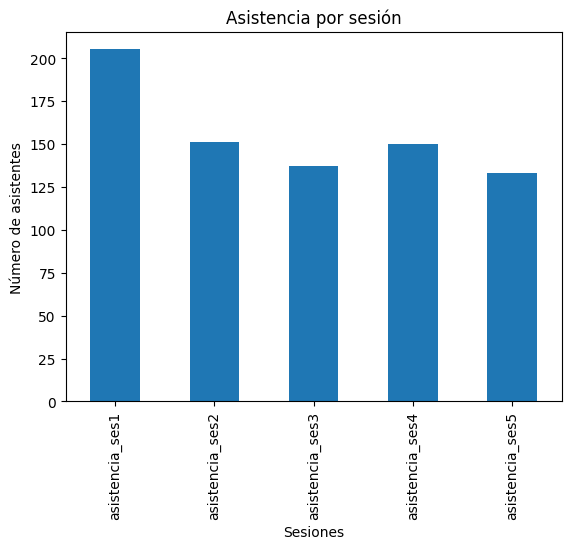

In [44]:

df_unicos[cols_asistencia].sum().plot(kind="bar")  #por ultimo, hacemos unas graficas sobre la asistencia

plt.title("Asistencia por sesión")
plt.xlabel("Sesiones")
plt.ylabel("Número de asistentes")
plt.show()

Arriba podemos observar las asistencias por sesion, vemos que la primera session fue la mas asistida

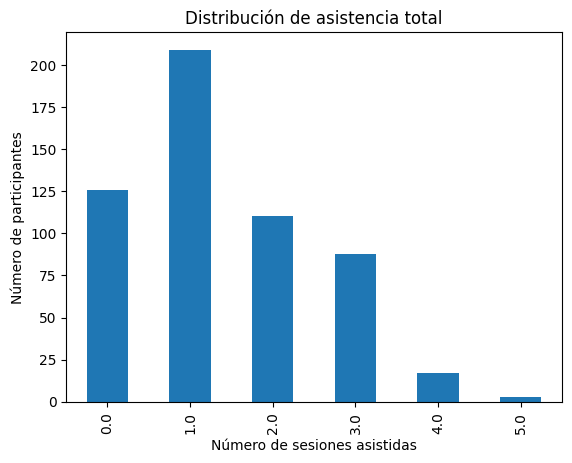

In [45]:
df_unicos["total_asistencia"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de asistencia total")
plt.xlabel("Número de sesiones asistidas")
plt.ylabel("Número de participantes")
plt.show()

Por ultimo vemos de los participantes sus asistencias, la mayor parte asistio al menos a una sesion.

In [46]:
peor_desempeno = df_unicos[df_unicos["total_asistencia"] == df_unicos["total_asistencia"].min()]
peor_desempeno[["nombre_completo","total_asistencia"]]

,nombre_completo,total_asistencia
0,Abigail Tec Cauich,0.0
2,Adalberto Alcocer Pat,0.0
3,Adalberto Gongora Melken,0.0
10,Alan Miguel Chi Chi,0.0
15,Alejandro Hernandez Chuc,0.0
...,...,...
520,Vicente Puc Beltran,0.0
533,William Rafael Chin Tilan,0.0
534,Wilson Alejandro Xiu Mas,0.0
535,Wilson Ismael Azarcoya Leon,0.0


Nuevamente mostramos a los peores participantes, siento 126 con ninuna asistencia a ninguna sesion.